In [38]:
import numpy as np
import torch
from liquid.liquid_ensemble.le_layer import LiquidEnsembleLayer
import torch.nn.functional as F
import random
from torch.distributions import Categorical
import math

import pandas as pd


def sim_batch(N: int = 10, BS: int = 1_000):

    Ds = []
    for _ in range(N):
        d = torch.rand((BS, N))
        t = random.random() + 0.001
        d = F.softmax(d / t, dim=1)
        Ds.append(d)

    p, D = LiquidEnsembleLayer.solve_delegation_many_sinks(
        Ds=Ds
    )

    return p, D

def batch_entropy(x: torch.Tensor):
    bs, n = x.shape
    dist = Categorical(probs=x)
    entropy = dist.entropy() / math.log(n)
    return entropy


def confidence_power_entropy(P: torch.Tensor, D: torch.Tensor):
    return batch_entropy(P)

def confidence_D_entropy(P: torch.Tensor, D: torch.Tensor):

    es = []
    for i in range(D.shape[1]):
        es.append(batch_entropy(D[:, i, :]))

    es = torch.stack(es)
    return 1 - torch.mean(es, dim=0)

def confidence_self_delegation(P: torch.Tensor, D: torch.Tensor):
    diagonal = D.diagonal(dim1=1, dim2=2)
    return torch.mean(diagonal, dim=1)





funcs = [confidence_self_delegation, confidence_D_entropy, confidence_power_entropy]
df = {f.__name__: [] for f in funcs}
batches = 10

for _ in range(batches):

    for func in funcs:
        P, D = sim_batch()
        df[func.__name__].extend(func(P, D).tolist())

In [39]:
df = pd.DataFrame(df)
df

,confidence_self_delegation,confidence_D_entropy,confidence_power_entropy
0,0.076612,0.322095,0.824890
1,0.080754,0.324309,0.897719
2,0.109127,0.267467,0.837575
3,0.128911,0.326028,0.834146
4,0.071841,0.328466,0.882170
...,...,...,...
9995,0.083452,0.103761,0.868212
9996,0.095181,0.157304,0.810070
9997,0.061439,0.156046,0.822938
9998,0.134406,0.154931,0.888770


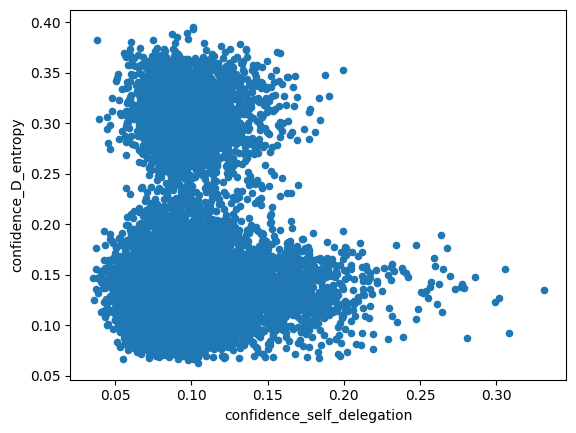

In [41]:
ax = df.plot.scatter("confidence_self_delegation", "confidence_D_entropy")

<Axes: xlabel='confidence_self_delegation', ylabel='confidence_power_entropy'>

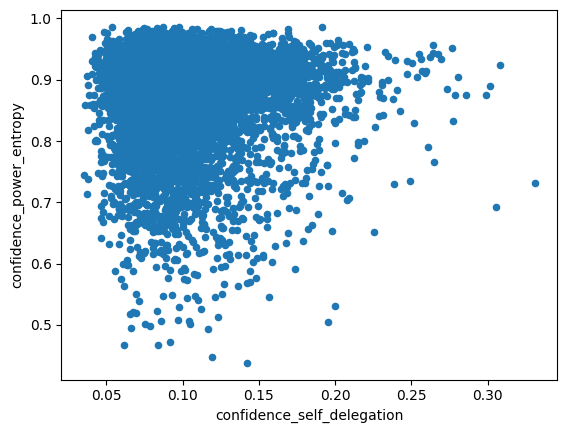

In [42]:
df.plot.scatter("confidence_self_delegation", "confidence_power_entropy")

<Axes: xlabel='confidence_D_entropy', ylabel='confidence_power_entropy'>

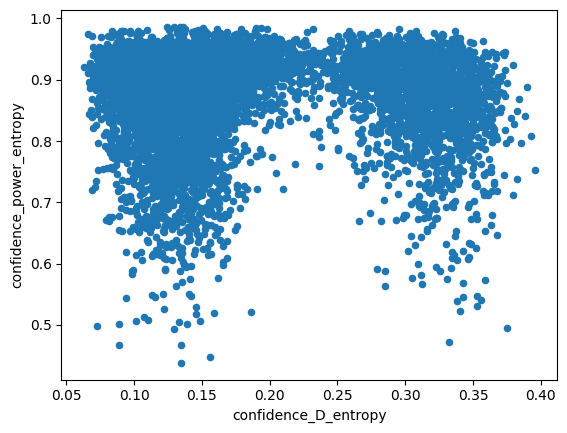

In [44]:
df.plot.scatter("confidence_D_entropy", "confidence_power_entropy")

In [46]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from typing import Tuple

def polynomial_significance_test(a: pd.Series, b: pd.Series, max_degree: int = 5) -> pd.DataFrame:
    assert len(a) == len(b), "Input series must be of the same length"
    results = []

    for degree in range(1, max_degree + 1):
        # Design matrix with polynomial features
        X = np.vander(a, N=degree + 1, increasing=True)
        model = sm.OLS(b, sm.add_constant(X)).fit()
        f_pvalue = model.f_pvalue
        results.append({
            "degree": degree,
            "R2": model.rsquared,
            "F-stat p-value": f_pvalue
        })

    return pd.DataFrame(results)


polynomial_significance_test(df["confidence_self_delegation"], df["confidence_D_entropy"])

,degree,R2,F-stat p-value
0,1,0.000038,5.366387e-01
1,2,0.010401,2.010434e-23
2,3,0.014258,6.464813e-31
3,4,0.014583,9.669471e-31
4,5,0.016393,7.647007e-34


In [ ]:
polynomial_significance_test(df["confidence_self_delegation"], df["confidence_power_entropy"])

,degree,R2,F-stat p-value
0,1,0.000045,0.500856
1,2,0.000258,0.275789
2,3,0.000423,0.237337
3,4,0.001541,0.003905
4,5,0.001554,0.008257


In [48]:
polynomial_significance_test(df["confidence_D_entropy"], df["confidence_power_entropy"])

,degree,R2,F-stat p-value
0,1,0.002860,8.758341e-08
1,2,0.021506,6.397850e-48
2,3,0.034171,5.015008e-75
3,4,0.045425,2.878556e-99
4,5,0.045598,1.358860e-98
